## Introduction

# Projet CO2 - Exploration des données

## Contexte
L'objectif de ce projet est d'analyser les émissions de CO₂ des véhicules commercialisés en France en 2014 afin d'identifier les facteurs influençant le niveau d'émissions et de préparer une future modélisation prédictive.

## Objectif

- Comprendre la structure du jeu de données
- Identifier les variables influençant les émissions de CO₂
- Mettre en évidence des tendances à l’aide de visualisations
- Préparer les données pour une future modélisation

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## Chargement des données 2014

Nous importons le jeu de données contenant les caractéristiques techniques et environnementales des véhicules commercialisés en France en 2014.

Le fichier est encodé en latin1 et utilise le séparateur ;. Ces paramètres doivent être précisés lors de l'importation afin de garantir une lecture correcte des données avec Pandas.

In [2]:
df_2014 = pd.read_csv("../data/co2_2014.csv", encoding="latin1", sep=";")
df_2014.head()

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147,...,1505,1505,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
1,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,12,147,...,1555,1555,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN


## Observation

Les premières lignes du jeu de données permettent d’identifier les principales variables disponibles, notamment la marque du véhicule, le type de carburant, la puissance moteur, la masse, la consommation et les émissions de CO₂. Ces informations laissent entrevoir plusieurs facteurs susceptibles d’influencer le niveau d’émissions des véhicules.

## Compréhension et structure des données

In [3]:
# Nombre de lignes et colonnes
df_2014.shape

(55044, 30)

Le jeu de données contient 55 044 observations et 30 variables.

Chaque ligne correspond à un modèle de véhicule homologué en France en 2014. Les variables décrivent notamment la marque, la motorisation, le carburant, la puissance, la consommation et les émissions de CO₂.

La taille du jeu de données est suffisante pour réaliser des analyses statistiques et explorer les relations entre les caractéristiques techniques des véhicules et leurs niveaux d’émissions.

In [4]:
# Informations générales
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  str    
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  str    
 12  conso_exurb        55001 non-null  str    
 13  conso_mixte        55010 non-null  str    
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  str    
 16  hc                 9773 non-null 

L'inspection de la structure du jeu de données met en évidence plusieurs variables quantitatives stockées au format texte (object), notamment les variables de consommation, de puissance et certains indicateurs liés aux émissions polluantes. Une conversion vers un format numérique sera nécessaire pour permettre les analyses statistiques et les visualisations.

Cette étape révèle également la présence de colonnes entièrement vides ainsi que plusieurs variables contenant des valeurs manquantes, qui feront l'objet d'une analyse spécifique lors du nettoyage des données.

In [5]:
# Statistiques descriptives
df_2014.describe(include='all')

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
count,55044,55044,55044,55044,55044,55044,55044,55044,55044.000000,55044,...,55044.000000,55044.000000,54983,3247,55044,55044,0.0,0.0,0.0,0.0
unique,46,483,434,3837,54982,35430,13,2,NaN,232,...,NaN,NaN,35,5,11,7,NaN,NaN,NaN,NaN
top,MERCEDES,VIANO,VIANO,VIANO 2.2 CDI,M10ALFVP000K441,F142ABE,GO,non,NaN,120,...,NaN,NaN,"""715/2007*692/2008EURO5",mars-14,MINIBUS,MOY-INFER,NaN,NaN,NaN,NaN
freq,36220,14031,14031,5874,2,4,49311,54655,NaN,19968,...,NaN,NaN,23979,2810,46107,33438,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.551504,NaN,...,2102.104553,2341.021801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.126021,NaN,...,294.731715,424.067895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,...,825.000000,825.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,...,1982.000000,2075.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,...,2076.000000,2355.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,...,2246.000000,2709.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Les statistiques descriptives mettent en évidence une forte diversité des véhicules présents dans le jeu de données, avec 46 marques et plusieurs centaines de modèles distincts. Les caractéristiques techniques, telles que la puissance et la masse des véhicules, présentent également une variabilité importante.

Cette première exploration confirme la richesse du dataset et permet d'identifier certaines variables nécessitant un traitement complémentaire, notamment les variables quantitatives stockées sous forme de texte ainsi que celles comportant des valeurs manquantes.

In [6]:
df_2014.isnull().sum()

lib_mrq                  0
lib_mod_doss             0
lib_mod                  0
dscom                    0
cnit                     0
tvv                      0
cod_cbr                  0
hybride                  0
puiss_admin_98           0
puiss_max                0
typ_boite_nb_rapp        0
conso_urb               43
conso_exurb             43
conso_mixte             34
co2                     34
co_typ_1               158
hc                   45271
nox                    158
hcnox                 9888
ptcl                  2678
masse_ordma_min          0
masse_ordma_max          0
champ_v9                61
date_maj             51797
Carrosserie              0
gamme                    0
Unnamed: 26          55044
Unnamed: 27          55044
Unnamed: 28          55044
Unnamed: 29          55044
dtype: int64

L'analyse des valeurs manquantes montre que la majorité des variables sont très bien renseignées. Quelques variables présentent un faible taux de données manquantes (moins de 1 %), tandis que certaines variables liées aux émissions polluantes secondaires, comme hc, nox, hcnox et ptcl, sont nettement moins complètes.

Les colonnes Unnamed: 26 à Unnamed: 29 sont entièrement vides et pourront être supprimées lors du nettoyage. La variable date_maj présente également une très forte proportion de valeurs manquantes (plus de 94 %) et fera l'objet d'une analyse afin d'évaluer sa pertinence pour l'étude.

Ces constats guideront les choix de nettoyage et de pré-processing réalisés dans la suite de l'analyse.

In [7]:
(df_2014.isnull().mean()*100).sort_values(ascending=False)

Unnamed: 27          100.000000
Unnamed: 26          100.000000
Unnamed: 29          100.000000
Unnamed: 28          100.000000
date_maj              94.101083
hc                    82.245113
hcnox                 17.963811
ptcl                   4.865199
nox                    0.287043
co_typ_1               0.287043
champ_v9               0.110820
conso_urb              0.078119
conso_exurb            0.078119
conso_mixte            0.061769
co2                    0.061769
typ_boite_nb_rapp      0.000000
puiss_admin_98         0.000000
hybride                0.000000
cod_cbr                0.000000
dscom                  0.000000
cnit                   0.000000
tvv                    0.000000
lib_mod_doss           0.000000
lib_mrq                0.000000
lib_mod                0.000000
puiss_max              0.000000
masse_ordma_max        0.000000
masse_ordma_min        0.000000
gamme                  0.000000
Carrosserie            0.000000
dtype: float64

L'analyse des pourcentages de valeurs manquantes confirme que la majorité des variables du jeu de données sont quasiment complètes. Les colonnes Unnamed: 26 à Unnamed: 29 sont entièrement vides (100 % de valeurs manquantes) et pourront être supprimées lors du nettoyage.

La variable date_maj présente également un taux très élevé de valeurs manquantes (94,1 %), ce qui nécessitera une évaluation de sa pertinence pour l'étude. Parmi les variables liées aux émissions polluantes, hc est manquante à plus de 82 %, tandis que hcnox présente près de 18 % de valeurs manquantes. À l'inverse, les variables principales du projet telles que co2, co_typ_1, nox, les consommations et les caractéristiques techniques des véhicules sont presque entièrement renseignées.

Ces résultats constituent un élément important pour définir la stratégie de nettoyage et de pré-processing qui sera appliquée avant la phase de modélisation.

## Structure des données

Le dataset 2014 contient 55 044 observations et 30 variables décrivant les caractéristiques techniques et environnementales des véhicules commercialisés en France.

Les données comprennent notamment :

la marque et le modèle des véhicules ;
le type de carburant ;
la puissance moteur ;
la consommation ;
la masse des véhicules ;
différentes mesures d'émissions polluantes, dont le CO₂.

L'analyse exploratoire met en évidence la présence de variables numériques et catégorielles, ainsi que plusieurs variables comportant un nombre important de valeurs manquantes (hc, hcnox, ptcl) et des colonnes entièrement vides (Unnamed).

Certaines variables quantitatives étaient également stockées au format texte et ont nécessité une conversion avant les analyses.

Dans l'ensemble, le dataset présente une qualité satisfaisante et apparaît exploitable pour l'étude des émissions de CO₂ et la préparation des étapes de pré-processing et de modélisation.

## Nettoyage minimal AVANT visualisations

## Supprimer les colonnes inutiles

In [8]:
df_2014 = df_2014.drop(columns=[
    'Unnamed: 26',
    'Unnamed: 27',
    'Unnamed: 28',
    'Unnamed: 29'
])

Les colonnes `Unnamed` correspondent à des colonnes vides générées lors de l’importation du fichier. Elles ne contiennent aucune information exploitable et sont donc supprimées.

## Convertir les colonnes numériques mal typées

In [9]:
colonnes_numeriques = [
    'puiss_max',
    'conso_urb',
    'conso_exurb',
    'conso_mixte',
    'hc',
    'nox',
    'hcnox',
    'ptcl',
    'co_typ_1'
]

for col in colonnes_numeriques:

    df_2014[col] = (
        df_2014[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    df_2014[col] = pd.to_numeric(
        df_2014[col],
        errors='coerce'
    )

Certaines variables quantitatives étaient stockées au format texte (object/string), notamment en raison de l'utilisation de virgules comme séparateur décimal. Une conversion vers un format numérique a été réalisée afin de permettre les calculs statistiques, les visualisations et les analyses de corrélation. Cette étape concerne notamment les variables de consommation, les polluants réglementaires et l'indicateur co_typ_1.

## Vérifier la conversion vers les nouveaux types

In [10]:
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  float64
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  float64
 12  conso_exurb        55001 non-null  float64
 13  conso_mixte        55010 non-null  float64
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  float64
 16  hc                 9773 non-null 

La vérification des types de données confirme que les variables quantitatives identifiées lors de l'analyse exploratoire ont été correctement converties au format numérique (float64). Les colonnes vides (Unnamed) ont également été supprimées, réduisant le dataset de 30 à 26 variables. Le jeu de données est désormais prêt pour les analyses statistiques et les visualisations.

## Analyse des corrélations

# Heatmap des valeurs manquantes

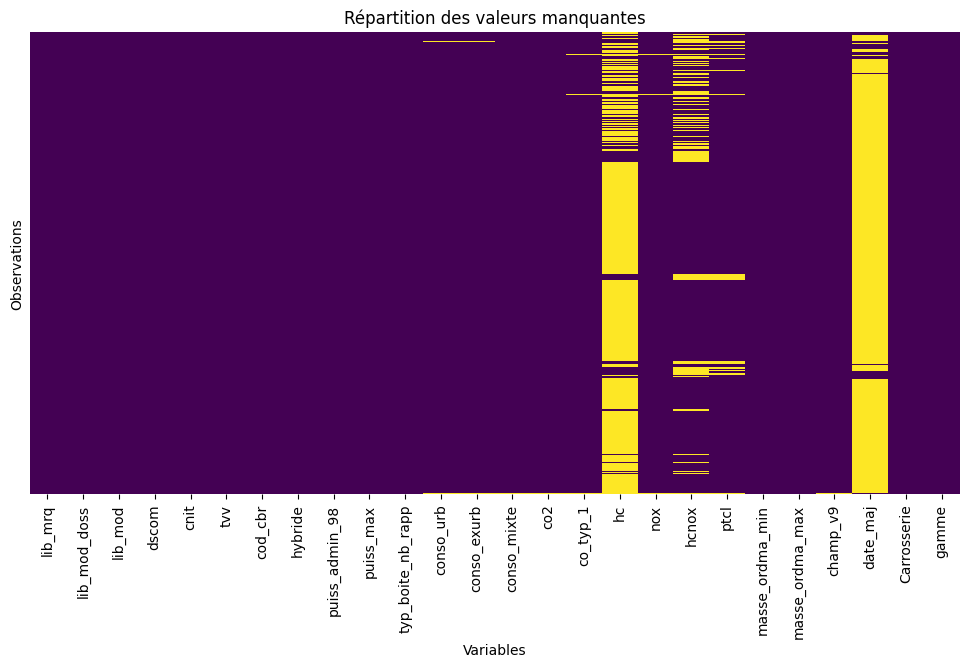

In [11]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df_2014.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Répartition des valeurs manquantes")
plt.xlabel("Variables")
plt.ylabel("Observations")

plt.show()

## Analyse des valeurs manquantes

La heatmap confirme que les données manquantes sont principalement concentrées dans les variables date_maj, hc, hcnox et, dans une moindre mesure, ptcl.

La variable date_maj présente un très faible taux de complétude, tandis que les variables environnementales hc, hcnox et ptcl comportent également un nombre important de valeurs manquantes.

À l'inverse, la majorité des autres variables sont correctement renseignées.

Ces variables seront réévaluées lors de la phase de pré-processing afin de déterminer leur intérêt pour la modélisation et les traitements à appliquer.

# Heatmap des corrélations

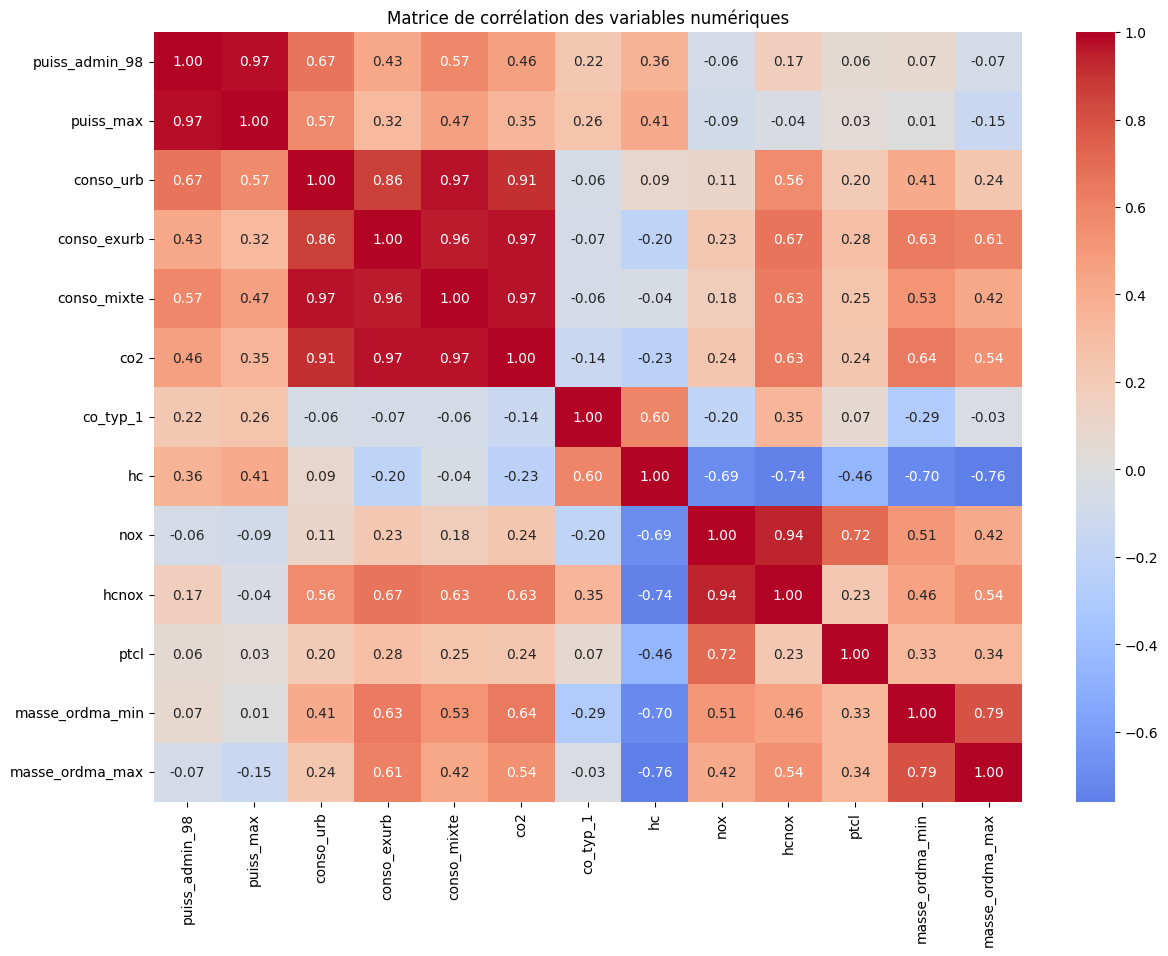

In [12]:
corr_matrix = df_2014.select_dtypes(include='number').corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0
)

plt.title("Matrice de corrélation des variables numériques")

plt.show()

## Interprétation de la matrice de corrélation

La matrice de corrélation met en évidence une très forte relation entre les émissions de CO₂ et les variables de consommation de carburant. Les corrélations les plus élevées sont observées pour la consommation mixte (conso_mixte, 0,97), la consommation extra-urbaine (conso_exurb, 0,97) et la consommation urbaine (conso_urb, 0,91). Ces résultats sont cohérents puisque les émissions de CO₂ sont directement liées à la quantité de carburant consommée par le véhicule.

La masse du véhicule constitue également un facteur important. Les variables masse_ordma_min (0,64) et masse_ordma_max (0,54) présentent des corrélations positives avec le CO₂, indiquant que les véhicules les plus lourds ont tendance à émettre davantage de CO₂.

Les variables environnementales présentent également des corrélations intéressantes avec les émissions de CO₂. La variable hcnox affiche une corrélation positive relativement élevée (0,63), tandis que nox et ptcl présentent des corrélations plus modérées. Ces résultats doivent toutefois être interprétés avec prudence en raison du nombre important de valeurs manquantes observé pour certaines de ces variables.

Les variables de puissance (puiss_admin_98 et puiss_max) présentent des corrélations positives mais plus modérées avec les émissions de CO₂. Leur influence semble donc moins importante que celle de la consommation de carburant ou de la masse du véhicule.

Enfin, la variable co_typ_1 présente une faible corrélation négative avec les émissions de CO₂ (-0,14), ce qui suggère qu'elle apporte peu d'information explicative directe sur le niveau d'émissions.

Cette analyse permet d'identifier les variables les plus pertinentes pour la suite du projet et oriente les futurs choix de pré-processing et de modélisation.

# Tableau des variables les plus corrélées au CO₂

In [13]:
co2_corr = (
    corr_matrix["co2"]
    .sort_values(ascending=False)
    .reset_index()
)

co2_corr.columns = ["Variable", "Corrélation avec CO₂"]

co2_corr

,Variable,Corrélation avec CO₂
0,co2,1.000000
1,conso_mixte,0.971183
2,conso_exurb,0.967704
3,conso_urb,0.909424
4,masse_ordma_min,0.643665
5,hcnox,0.632166
6,masse_ordma_max,0.540156
7,puiss_admin_98,0.463154
8,puiss_max,0.347086
9,nox,0.242836


## Analyse des variables les plus corrélées au CO₂

Les résultats confirment que les variables les plus fortement corrélées aux émissions de CO₂ sont les différentes mesures de consommation de carburant, en particulier conso_mixte (0,97), conso_exurb (0,97) et conso_urb (0,91). La masse du véhicule apparaît également comme un facteur explicatif important, avec des corrélations positives pour masse_ordma_min (0,64) et masse_ordma_max (0,54).

Parmi les variables environnementales, hcnox présente une corrélation relativement élevée avec le CO₂ (0,63), tandis que nox et ptcl affichent des corrélations plus modérées. Ces résultats doivent toutefois être interprétés avec prudence en raison du nombre important de valeurs manquantes observé pour certaines de ces variables.

Enfin, co_typ_1 et hc présentent de faibles corrélations négatives avec les émissions de CO₂.

Ces résultats doivent toutefois être interprétés avec prudence en raison du nombre important de valeurs manquantes observées pour certaines de ces variables.

## Analyse multivariée

# Pairplot

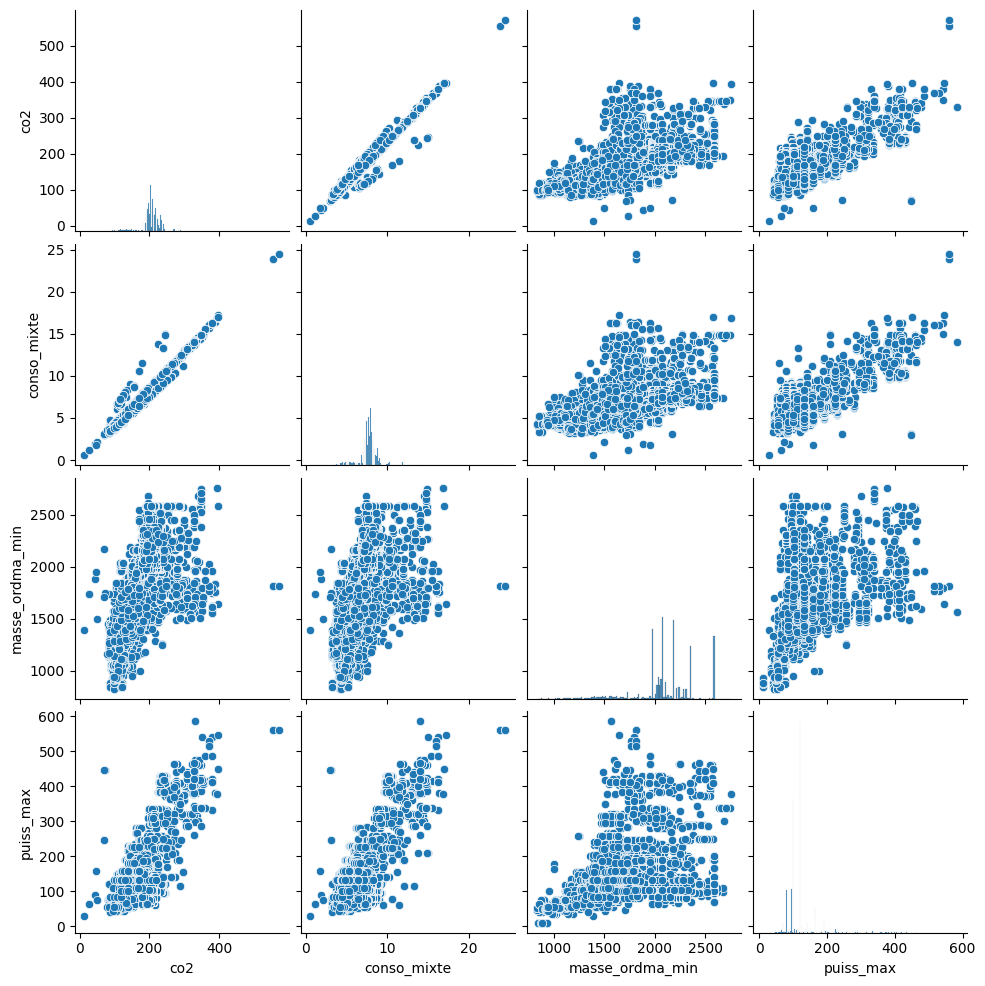

In [14]:
variables_pairplot = [
    'co2',
    'conso_mixte',
    'masse_ordma_min',
    'puiss_max'
]

sns.pairplot(
    df_2014[variables_pairplot],
    diag_kind="hist"
)

plt.show()

## Interprétation du Pairplot

Le pairplot permet d'examiner simultanément les distributions individuelles des variables ainsi que les relations entre elles.

On observe une relation très forte entre la consommation mixte (conso_mixte) et les émissions de CO₂ (co2). Les véhicules consommant davantage de carburant sont également ceux qui émettent le plus de CO₂, ce qui confirme les résultats observés dans la matrice de corrélation.

La masse du véhicule (masse_ordma_min) présente également une relation positive avec les émissions de CO₂. Les véhicules les plus lourds tendent à être plus polluants, même si cette relation est moins marquée que celle observée avec la consommation.

La puissance maximale du moteur (puiss_max) est elle aussi positivement liée aux émissions de CO₂. Les véhicules les plus puissants affichent globalement des niveaux d'émissions plus élevés, ce qui traduit l'influence de la motorisation sur la consommation et les rejets de CO₂.

Les distributions visibles sur la diagonale montrent que certaines variables sont concentrées autour de plages de valeurs spécifiques, reflétant la prédominance de certaines catégories de véhicules dans le dataset.

Dans l'ensemble, ce pairplot confirme que la consommation de carburant constitue le facteur le plus fortement associé aux émissions de CO₂, tandis que la masse et la puissance du véhicule exercent également une influence significative. Ces variables apparaissent comme particulièrement pertinentes pour les futures étapes de modélisation.

## Visualisations exploratoires

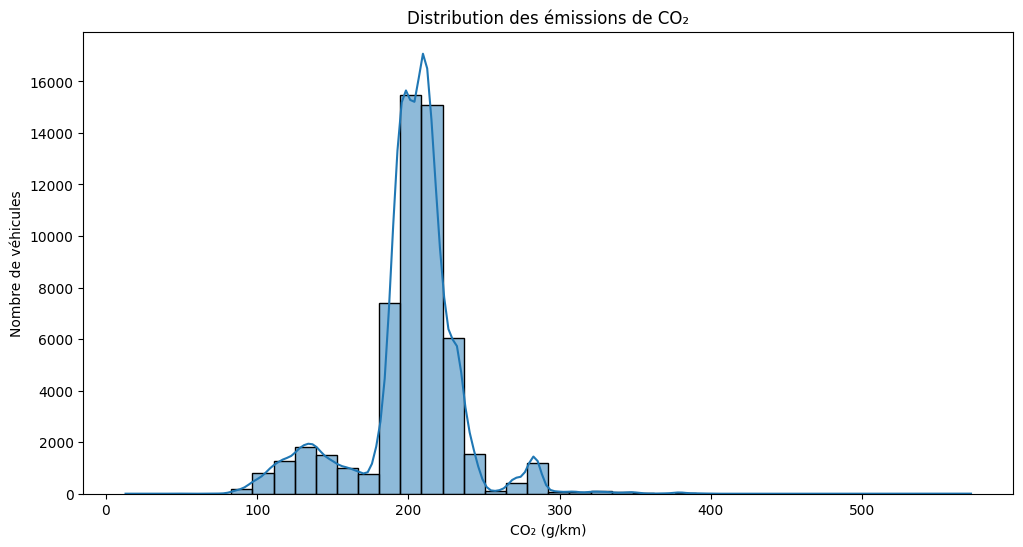

In [15]:
plt.figure(figsize=(12,6))

sns.histplot(df_2014['co2'], bins=40, kde=True)

plt.title("Distribution des émissions de CO₂")
plt.xlabel("CO₂ (g/km)")
plt.ylabel("Nombre de véhicules")

plt.show()

## Analyse de la distribution des émissions de CO₂

La distribution des émissions de CO₂ des véhicules commercialisés en France en 2014 montre une forte concentration des observations entre 180 et 230 g/km.

La distribution présente une asymétrie vers la droite, traduisant la présence de véhicules fortement émetteurs. Quelques valeurs extrêmes dépassent 300 g/km.

On observe également plusieurs pics dans la distribution, ce qui peut s'expliquer par la coexistence de différentes catégories de véhicules, motorisations et types de carburants.

La majorité des véhicules reste néanmoins regroupée autour des valeurs moyennes d'émission.

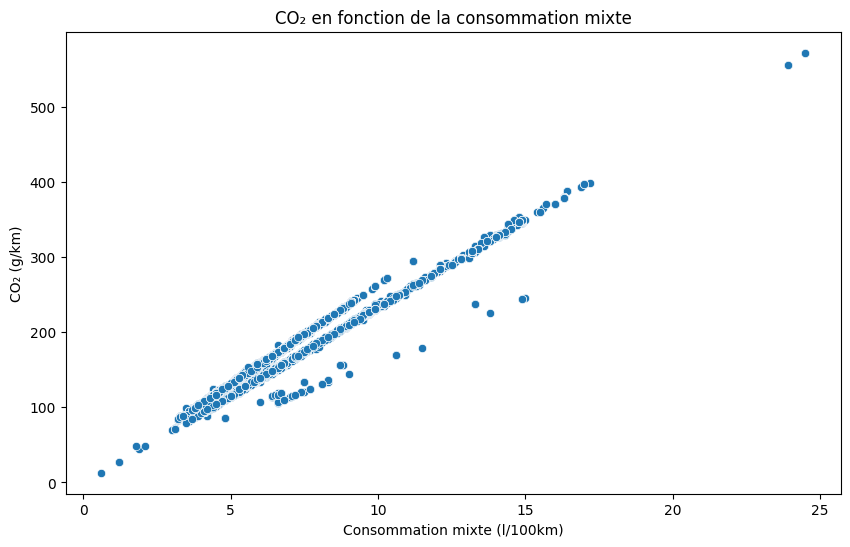

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='conso_mixte',
    y='co2',
    data=df_2014
)

plt.title("CO₂ en fonction de la consommation mixte")
plt.xlabel("Consommation mixte (l/100km)")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ en fonction de la consommation mixte

Le graphique met en évidence une relation positive très marquée entre la consommation mixte des véhicules et leurs émissions de CO₂.

Plus la consommation de carburant augmente, plus les émissions de CO₂ augmentent également. Les points sont fortement alignés, ce qui traduit une relation quasi linéaire entre les deux variables.

Les véhicules les plus consommateurs, au-delà de 12 l/100 km, présentent logiquement les niveaux d'émissions les plus élevés.

Cette observation confirme que la consommation mixte constitue l'un des principaux facteurs explicatifs des émissions de CO₂ dans le dataset et qu'elle représente une variable particulièrement pertinente pour les futures étapes de modélisation.

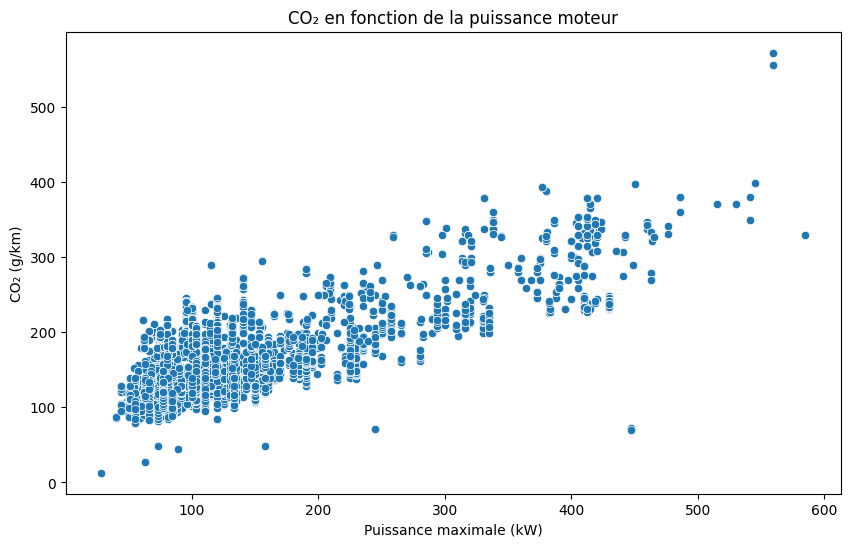

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='puiss_max',
    y='co2',
    data=df_2014
)

plt.title("CO₂ en fonction de la puissance moteur")
plt.xlabel("Puissance maximale (kW)")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ en fonction de la puissance moteur

Le graphique met en évidence une relation positive entre la puissance maximale du moteur et les émissions de CO₂.

Globalement, les véhicules les plus puissants tendent à émettre davantage de CO₂. Cette tendance apparaît par une augmentation progressive des émissions lorsque la puissance moteur augmente.

Toutefois, la dispersion des points est nettement plus importante que celle observée entre la consommation mixte et les émissions de CO₂. Cette variabilité indique que la puissance moteur n'explique qu'une partie des émissions observées.

D'autres facteurs, tels que la consommation de carburant, la masse du véhicule ou encore le type de motorisation, semblent également jouer un rôle important.

Cette observation est cohérente avec la corrélation modérée observée entre la puissance maximale et les émissions de CO₂ (0,35), inférieure à celle des variables de consommation.

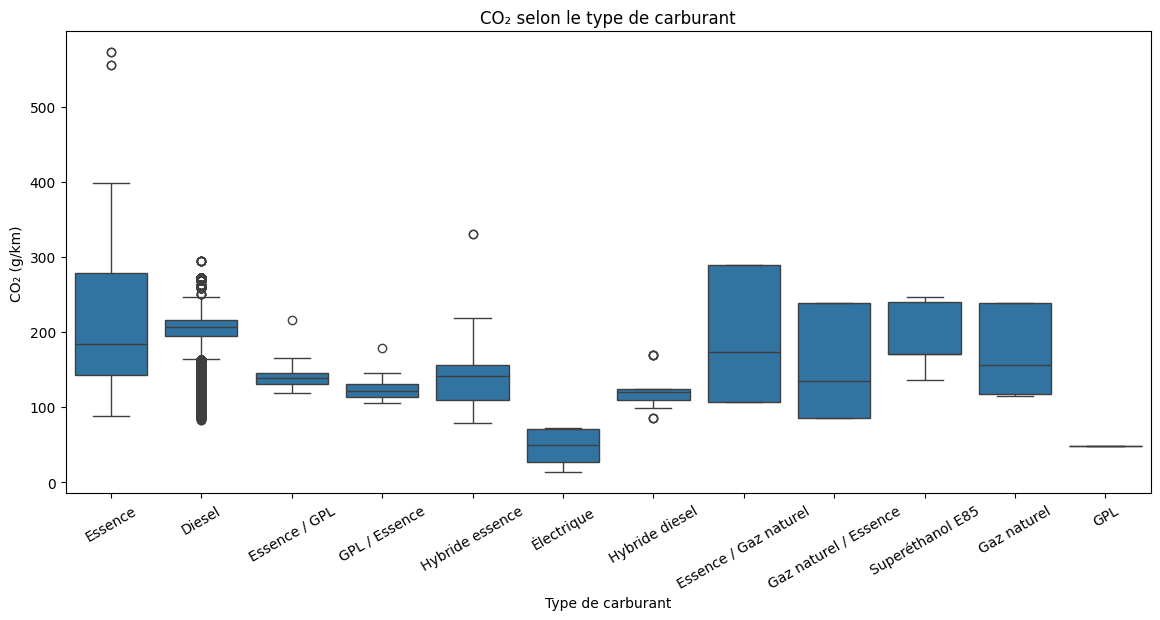

In [18]:
carburants = {
    'ES': 'Essence',
    'GO': 'Diesel',
    'EE': 'Électrique',
    'EH': 'Hybride essence',
    'GH': 'Hybride diesel',
    'ES/GN': 'Essence / Gaz naturel',
    'GN/ES': 'Gaz naturel / Essence',
    'FE': 'Superéthanol E85',
    'GN': 'Gaz naturel',
    'GL': 'GPL',
    'GP/ES': 'GPL / Essence',
    'ES/GP': 'Essence / GPL'
}
df_2014['carburant_libelle'] = df_2014['cod_cbr'].map(carburants)

plt.figure(figsize=(14,6))

sns.boxplot(
    x='carburant_libelle',
    y='co2',
    data=df_2014
)

plt.xticks(rotation=30)

plt.title("CO₂ selon le type de carburant")
plt.xlabel("Type de carburant")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ selon le type de carburant

Ce graphique met en évidence des différences notables d’émissions de CO₂ selon le type de carburant utilisé par les véhicules.

Les véhicules fonctionnant à l’essence présentent une forte dispersion des émissions ainsi que plusieurs valeurs extrêmes dépassant 500 g/km, correspondant probablement à des véhicules très puissants ou sportifs.

Les véhicules diesel affichent des émissions généralement élevées mais plus concentrées autour de leur médiane. À l’inverse, les véhicules électriques présentent les niveaux d’émissions les plus faibles du dataset.

Les motorisations hybrides et certains carburants alternatifs semblent globalement associés à des émissions plus faibles. Toutefois, certaines catégories comportent un nombre limité d’observations, ce qui invite à interpréter ces résultats avec prudence.

Cette analyse confirme que le type de carburant constitue un facteur important dans la variabilité des émissions de CO₂ observées.

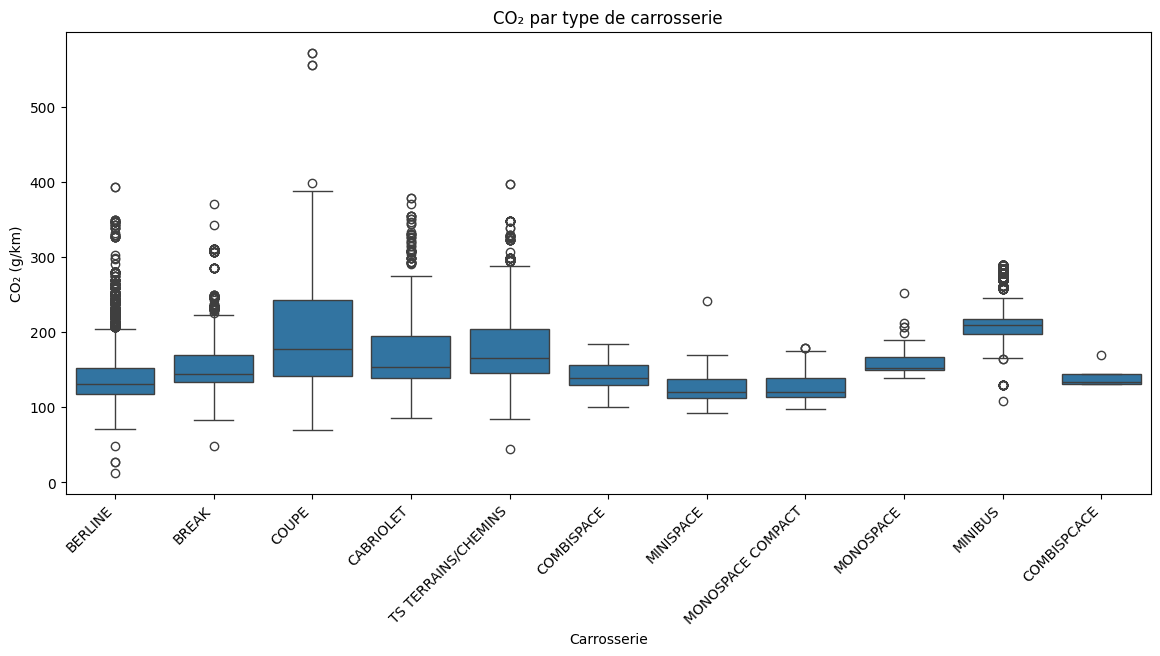

In [19]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x='Carrosserie',
    y='co2',
    data=df_2014
)

plt.xticks(rotation=45, ha='right')

plt.title("CO₂ par type de carrosserie")
plt.xlabel("Carrosserie")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ par type de carrosserie

Le graphique met en évidence des différences d’émissions de CO₂ selon les types de carrosserie des véhicules.

Les coupés présentent globalement les niveaux d’émissions les plus élevés ainsi que la plus forte dispersion des valeurs. Les minibus et les véhicules de type TS terrains/chemins affichent également des émissions relativement importantes.

À l’inverse, les minispaces, monospaces compacts et combispaces présentent des émissions généralement plus faibles et plus homogènes.

La présence de nombreux points atypiques (outliers) montre que certains modèles particuliers émettent des quantités de CO₂ nettement supérieures à la moyenne de leur catégorie.

Ces résultats suggèrent que le type de carrosserie influence les émissions de CO₂, probablement en lien avec des caractéristiques telles que la masse du véhicule, sa puissance ou son usage.

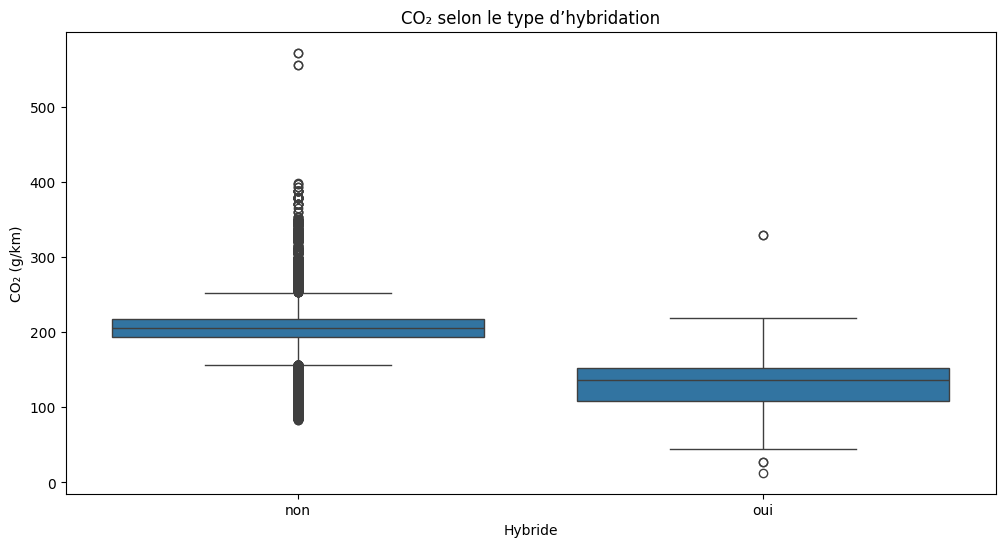

In [20]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='hybride',
    y='co2',
    data=df_2014
)

plt.title("CO₂ selon le type d’hybridation")
plt.xlabel("Hybride")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ selon le type d’hybridation

Le graphique compare les émissions de CO₂ des véhicules hybrides et non hybrides.

Les véhicules hybrides présentent globalement des émissions de CO₂ plus faibles que les véhicules non hybrides. Leur médiane d’émission est nettement inférieure, ce qui suggère un effet positif de l’hybridation sur la réduction des émissions polluantes.

Les véhicules non hybrides affichent une dispersion plus importante ainsi qu’un nombre élevé de valeurs extrêmes, avec certains modèles dépassant largement les 300 g/km de CO₂.

Bien que quelques véhicules hybrides présentent également des émissions élevées, la distribution globale reste significativement plus faible que celle observée pour les véhicules non hybrides.

Cette analyse met en évidence l’intérêt des technologies hybrides dans la réduction des émissions de CO₂ des véhicules commercialisés en France en 2014.

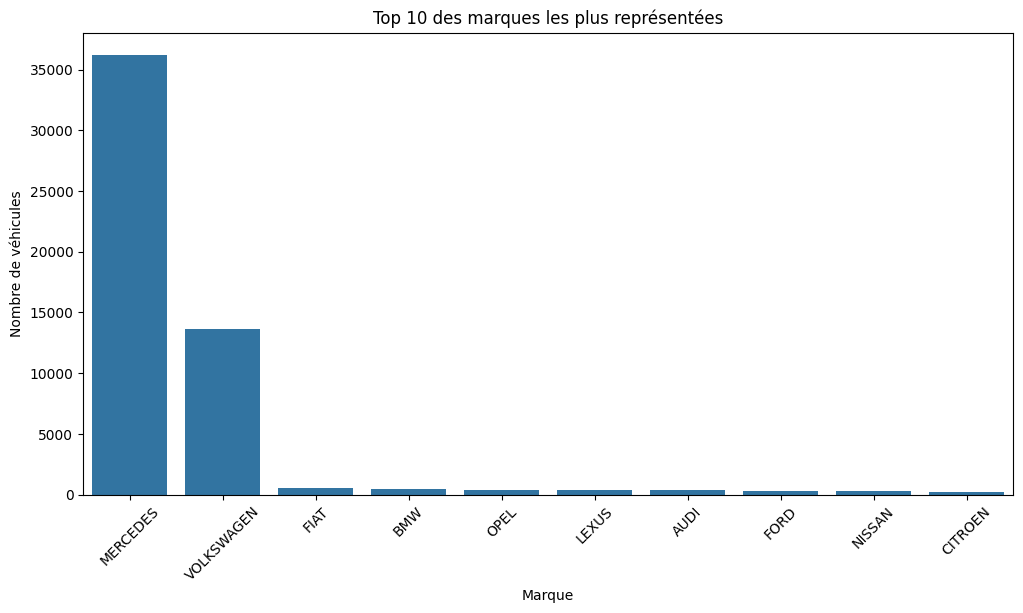

In [21]:
# Top 10 des marques les plus représentées

top_marques_rep = (
    df_2014['lib_mrq']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_marques_rep.index,
    y=top_marques_rep.values
)

plt.xticks(rotation=45)
plt.title("Top 10 des marques les plus représentées")
plt.xlabel("Marque")
plt.ylabel("Nombre de véhicules")

plt.show()

# Analyse des marques les plus représentées

Le graphique met en évidence une très forte concentration du jeu de données autour des marques Mercedes et Volkswagen.

Mercedes représente à elle seule plus de 36 000 observations, tandis que Volkswagen dépasse les 13 000 observations. Les autres marques apparaissent dans des proportions nettement plus faibles.

Cette répartition très déséquilibrée suggère que certaines marques disposent d'un nombre beaucoup plus important de modèles ou de variantes techniques référencés dans la base de données.

Il convient toutefois de rappeler que ce classement reflète la représentation des véhicules dans le dataset et non leur part réelle dans le parc automobile français.

La comparaison avec les émissions de CO₂ permettra de déterminer si les marques les plus représentées sont également les plus émettrices.

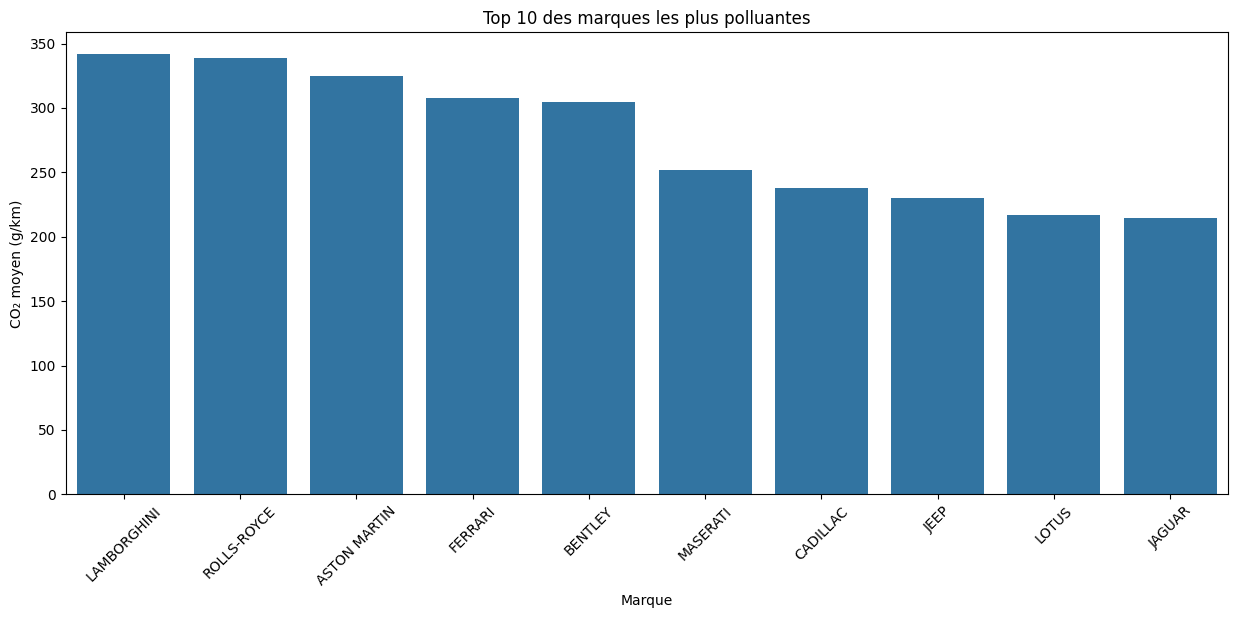

In [22]:
top_marques = (
    df_2014.groupby('lib_mrq')['co2']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(15,6))

sns.barplot(
    x=top_marques.index,
    y=top_marques.values
)

plt.xticks(rotation=45)

plt.title("Top 10 des marques les plus polluantes")
plt.xlabel("Marque")
plt.ylabel("CO₂ moyen (g/km)")

plt.show()

## Analyse des marques les plus polluantes

Le graphique présente les dix marques affichant les émissions moyennes de CO₂ les plus élevées du jeu de données.

Les premières positions sont occupées par Lamborghini, Rolls-Royce, Aston Martin, Ferrari et Bentley, des constructeurs principalement spécialisés dans les véhicules sportifs, luxueux ou de très forte puissance.

Ces résultats sont cohérents avec les caractéristiques de ces véhicules, généralement plus puissants, plus lourds et plus consommateurs de carburant.

Cette analyse met en évidence le lien entre les performances automobiles et le niveau moyen d'émissions de CO₂.

# Comparaison entre présence et niveau d'émissions

Les marques les plus polluantes ne figurent pas parmi les marques les plus représentées du dataset.

À l'inverse, Mercedes et Volkswagen dominent largement en nombre d'observations sans apparaître dans le classement des émissions moyennes les plus élevées.

Cela montre que la représentativité d'une marque dans le jeu de données et son niveau moyen d'émissions constituent deux dimensions distinctes qui doivent être analysées séparément.

Bien que certaines marques de prestige affichent des émissions très élevées, leur faible représentation limite probablement leur contribution globale aux émissions observées dans le dataset.

## Tests statistiques complémentaires
Corrélation de Pearson

Corrélation de Spearman

Test de Student

ANOVA (carburant)

ANOVA (hybridation)

Khi-deux (si pertinent)



## Conclusion des tests statistiques

Les tests statistiques confirment les tendances observées lors de l'analyse exploratoire.

La consommation de carburant apparaît comme le principal facteur explicatif des émissions de CO₂. La puissance, le type de carburant et l'hybridation exercent également une influence significative sur les niveaux d'émissions.

Ces résultats renforcent la pertinence des variables retenues pour les futures étapes de prétraitement et de modélisation prédictive.

## Conclusion générale de l'analyse exploratoire

L'analyse exploratoire du jeu de données 2014 a permis d'identifier les principaux facteurs associés aux émissions de CO₂ des véhicules commercialisés en France.

Les analyses descriptives ont mis en évidence une forte diversité des véhicules étudiés en termes de motorisation, de puissance, de masse et de consommation de carburant. Malgré la présence de certaines valeurs manquantes sur quelques variables environnementales, la qualité globale des données apparaît satisfaisante pour la poursuite du projet.

Les visualisations réalisées montrent une relation très forte entre les émissions de CO₂ et les différentes mesures de consommation de carburant. Les véhicules consommant davantage de carburant présentent systématiquement des niveaux d'émissions plus élevés. La consommation apparaît comme le principal facteur explicatif des émissions de CO₂, tandis que la puissance du moteur et la masse du véhicule exercent également une influence importante.

L'étude selon le type de carburant met en évidence des différences significatives entre les catégories de véhicules. Les motorisations hybrides et électriques affichent globalement les niveaux d'émissions les plus faibles, tandis que les motorisations thermiques présentent des émissions plus élevées et plus dispersées.

L'analyse des marques automobiles révèle que les constructeurs les plus représentés dans le jeu de données ne sont pas nécessairement les plus polluants. À l'inverse, plusieurs marques spécialisées dans les véhicules sportifs ou de prestige affichent des émissions moyennes de CO₂ particulièrement élevées malgré une présence plus limitée dans le dataset.

Les tests statistiques complémentaires confirment les observations réalisées lors de l'analyse graphique. Les corrélations, les tests de comparaison de moyennes et les analyses de variance montrent que les relations observées entre les émissions de CO₂ et les caractéristiques des véhicules sont statistiquement significatives et ne sont pas dues au hasard.

Au regard de ces résultats, les variables liées à la consommation, à la masse, à la puissance et au type de motorisation apparaissent comme les candidates les plus pertinentes pour la suite du projet.

La prochaine étape consistera à réaliser les opérations de prétraitement des données (gestion des valeurs manquantes, encodage des variables catégorielles, normalisation et création éventuelle de nouvelles variables) afin d'obtenir un jeu de données prêt pour les phases de modélisation prédictive des émissions de CO₂.

## Tests statistiques complémentaires

## Corrélations (Pearson / Spearman)

=== TEST 1 — Pearson & Spearman ===

conso_mixte
  Pearson  r=+0.9712 | p=0.00e+00
  Spearman r=+0.9867 | p=0.00e+00
  n=55010

conso_urb
  Pearson  r=+0.9094 | p=0.00e+00
  Spearman r=+0.9226 | p=0.00e+00
  n=55001

conso_exurb
  Pearson  r=+0.9677 | p=0.00e+00
  Spearman r=+0.9034 | p=0.00e+00
  n=55001

puiss_max
  Pearson  r=+0.3471 | p=0.00e+00
  Spearman r=+0.1415 | p=6.89e-244
  n=55010

puiss_admin_98
  Pearson  r=+0.4632 | p=0.00e+00
  Spearman r=+0.3868 | p=0.00e+00
  n=55010

masse_ordma_min
  Pearson  r=+0.6437 | p=0.00e+00
  Spearman r=+0.4891 | p=0.00e+00
  n=55010



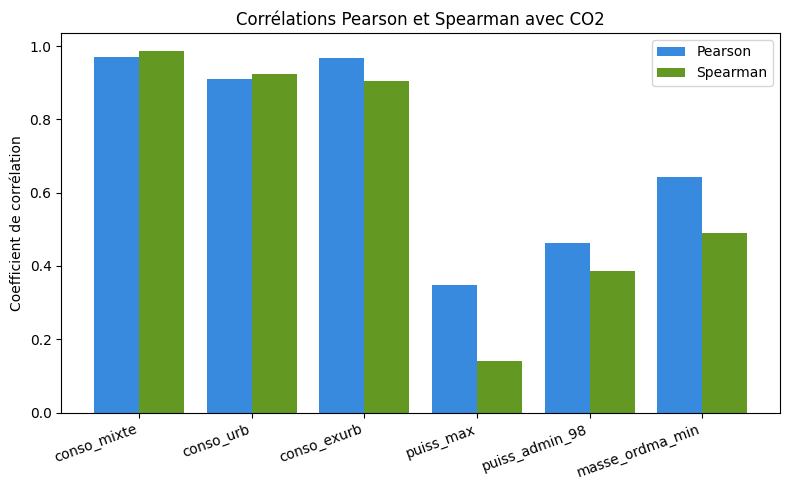

In [26]:
# ============================================================
# TEST 1 — PEARSON & SPEARMAN (variables numériques vs CO2)
# ============================================================

vars_num = ['conso_mixte', 'conso_urb', 'conso_exurb',
            'puiss_max', 'puiss_admin_98', 'masse_ordma_min']

print("=== TEST 1 — Pearson & Spearman ===\n")

for var in vars_num:
    sous_df = df_2014[['co2', var]].dropna()
    rp, pp = stats.pearsonr(sous_df[var], sous_df['co2'])
    rs, ps = stats.spearmanr(sous_df[var], sous_df['co2'])
    print(f"{var}")
    print(f"  Pearson  r={rp:+.4f} | p={pp:.2e}")
    print(f"  Spearman r={rs:+.4f} | p={ps:.2e}")
    print(f"  n={len(sous_df)}\n")

# Visualisation
plt.figure(figsize=(8, 5))
correlations_pearson  = [stats.pearsonr(df_2014[['co2', v]].dropna()[v],
                                         df_2014[['co2', v]].dropna()['co2'])[0] for v in vars_num]
correlations_spearman = [stats.spearmanr(df_2014[['co2', v]].dropna()[v],
                                          df_2014[['co2', v]].dropna()['co2'])[0] for v in vars_num]

x = np.arange(len(vars_num))
plt.bar(x - 0.2, correlations_pearson,  width=0.4, label='Pearson',  color='#378ADD')
plt.bar(x + 0.2, correlations_spearman, width=0.4, label='Spearman', color='#639922')
plt.xticks(x, vars_num, rotation=20, ha='right')
plt.ylabel('Coefficient de corrélation')
plt.title('Corrélations Pearson et Spearman avec CO2')
plt.legend()
plt.tight_layout()
plt.show()

## Interprétation

Les tests de corrélation de Pearson et de Spearman mettent en évidence des relations statistiquement significatives entre les émissions de CO₂ et l'ensemble des variables étudiées (p-value < 0,05).

Les variables de consommation (`conso_mixte`, `conso_urb` et `conso_exurb`) présentent les corrélations les plus fortes avec les émissions de CO₂, avec des coefficients supérieurs à 0,90. Ce résultat est cohérent puisque la consommation de carburant est directement liée aux émissions produites par le véhicule.

La masse du véhicule (`masse_ordma_min`) présente également une corrélation positive modérée à forte (r = 0,64), suggérant que les véhicules plus lourds tendent à émettre davantage de CO₂.

À l'inverse, la puissance maximale (`puiss_max`) présente la corrélation la plus faible parmi les variables étudiées (r = 0,35), indiquant une relation moins marquée avec les émissions de CO₂.